In [85]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

# Load the results
RESULTS_FILE = "grid_search_results_100.json"

with open(RESULTS_FILE) as f:
    data = json.load(f)

print(f"Loaded results from: {RESULTS_FILE}")
print(f"Timestamp: {data['timestamp']}")
print(f"Number of folds: {data['n_folds']}")
print(f"Number of experiments: {len(data['results'])}")
print(f"Use SHAP: {data['use_shap']}")
print(f"Use LightGBM defaults: {data['use_lightgbm_default']}")


Loaded results from: grid_search_results_100.json
Timestamp: 2025-12-12T02:52:50.931120
Number of folds: 10
Number of experiments: 72
Use SHAP: True
Use LightGBM defaults: False


## Convert to DataFrame

Create a summary dataframe with mean and std of metrics across folds for each parameter configuration.


In [86]:
# Build summary dataframe
rows = []
for exp in data['results']:
    params = exp['full_params']
    fold_results = exp['fold_results']
    
    train_mses = [f['train_mse'] for f in fold_results]
    test_mses = [f['test_mse'] for f in fold_results]
    
    row = {
        # Parameters (only varying ones)
        'drop_rate': params.get('drop_rate'),
        'feature_fraction_bynode': params.get('feature_fraction_bynode'),
        'learning_rate': params.get('learning_rate'),
        'num_leaves': params.get('num_leaves'),
        'max_depth': params.get('max_depth'),
        # Metrics
        'train_mse_mean': np.mean(train_mses),
        'train_mse_std': np.std(train_mses),
        'test_mse_mean': np.mean(test_mses),
        'test_mse_std': np.std(test_mses),
        'test_mse_min': np.min(test_mses),
        'test_mse_max': np.max(test_mses),
        # Overfitting indicator
        'overfit_ratio': np.mean(test_mses) / np.mean(train_mses),
    }
    rows.append(row)

df = pd.DataFrame(rows)
print(f"Summary dataframe shape: {df.shape}")
df.head(10)


Summary dataframe shape: (72, 12)


,drop_rate,feature_fraction_bynode,learning_rate,num_leaves,max_depth,train_mse_mean,train_mse_std,test_mse_mean,test_mse_std,test_mse_min,test_mse_max,overfit_ratio
0,0.025,0.2,0.1,50,10,13.420394,17.733857,45.639421,28.489213,18.848998,101.355273,3.400751
1,0.025,0.2,0.1,100,10,4.936491,2.997793,35.646875,22.370505,15.599435,90.043677,7.221097
2,0.025,0.2,0.1,200,10,5.086684,4.036428,37.220667,22.088735,15.517710,89.882479,7.317275
3,0.025,0.2,0.2,50,10,3.683014,2.354709,34.109547,17.331090,17.440226,70.665542,9.261314
4,0.025,0.2,0.2,100,10,2.851243,3.617977,35.341411,18.583142,14.860010,69.698787,12.395088
5,0.025,0.2,0.2,200,10,2.535438,3.744632,38.096181,22.041497,16.733245,83.149926,15.025482
6,0.025,0.2,0.3,50,10,2.222873,0.505796,35.947782,20.630728,15.518749,74.657291,16.171764
7,0.025,0.2,0.3,100,10,1.326140,0.644889,34.043805,18.194561,15.539327,70.332308,25.671353
8,0.025,0.2,0.3,200,10,0.928764,0.459571,34.030184,17.220576,16.739265,64.924128,36.640306
9,0.025,0.4,0.1,50,10,12.489727,16.993489,45.852182,29.326989,17.707845,102.565610,3.671192


## Overall Statistics


In [87]:
df[['train_mse_mean', 'test_mse_mean', 'test_mse_std', 'overfit_ratio']].describe()


,train_mse_mean,test_mse_mean,test_mse_std,overfit_ratio
count,72.000000,72.000000,72.000000,72.000000
mean,7.887566,41.557002,27.106207,11.232288
std,7.946201,8.732479,7.746670,8.732694
min,0.925913,32.153160,17.220576,2.277102
25%,2.352489,35.410366,22.007724,3.651746
50%,4.231337,37.445558,25.723304,9.104238
75%,12.722393,46.148436,29.077529,15.050130
max,27.053908,61.604495,51.819502,39.148636


## Best Configurations

Top 10 configurations ranked by mean test MSE (lower is better).


In [88]:
best_configs = df.sort_values('test_mse_mean').head(10)
best_configs[['drop_rate', 'feature_fraction_bynode', 'learning_rate', 'num_leaves', 
              'test_mse_mean', 'test_mse_std', 'train_mse_mean', 'overfit_ratio']]


,drop_rate,feature_fraction_bynode,learning_rate,num_leaves,test_mse_mean,test_mse_std,train_mse_mean,overfit_ratio
26,0.050,0.2,0.3,200,32.153160,17.741218,1.216718,26.426145
25,0.050,0.2,0.3,100,33.104641,19.250473,1.452842,22.786122
8,0.025,0.2,0.3,200,34.030184,17.220576,0.928764,36.640306
7,0.025,0.2,0.3,100,34.043805,18.194561,1.326140,25.671353
3,0.025,0.2,0.2,50,34.109547,17.331090,3.683014,9.261314
35,0.050,0.4,0.3,200,34.174057,20.377570,1.071467,31.894633
21,0.050,0.2,0.2,50,34.401165,20.255858,4.432627,7.760898
22,0.050,0.2,0.2,100,34.503625,19.692894,3.142359,10.980166
34,0.050,0.4,0.3,100,34.670916,22.393709,1.302029,26.628371
61,0.200,0.2,0.3,100,34.949106,23.839824,2.359957,14.809213


## Worst Configurations

Bottom 10 configurations ranked by mean test MSE.


In [89]:
worst_configs = df.sort_values('test_mse_mean', ascending=False).head(10)
worst_configs[['drop_rate', 'feature_fraction_bynode', 'learning_rate', 'num_leaves', 
               'test_mse_mean', 'test_mse_std', 'train_mse_mean', 'overfit_ratio']]


,drop_rate,feature_fraction_bynode,learning_rate,num_leaves,test_mse_mean,test_mse_std,train_mse_mean,overfit_ratio
54,0.2,0.2,0.1,50,61.604495,37.256659,27.053908,2.277102
63,0.2,0.4,0.1,50,60.311174,35.653200,25.236120,2.389875
45,0.1,0.4,0.1,50,60.081664,47.782649,24.922518,2.410738
38,0.1,0.2,0.1,200,59.991185,51.819502,22.809064,2.630147
56,0.2,0.2,0.1,200,59.669832,40.038254,23.854212,2.501438
64,0.2,0.4,0.1,100,58.818466,36.185880,23.836497,2.467580
46,0.1,0.4,0.1,100,58.254998,47.432874,21.986224,2.649614
55,0.2,0.2,0.1,100,58.236713,37.888105,23.311119,2.498238
37,0.1,0.2,0.1,100,57.461062,47.725875,22.174595,2.591301
65,0.2,0.4,0.1,200,57.275269,35.365398,20.919712,2.737861


## Parameter Impact Analysis

Average test MSE for each parameter value to understand which settings tend to perform better.


In [90]:
param_cols = ['drop_rate', 'feature_fraction_bynode', 'learning_rate', 'num_leaves']

print("Mean Test MSE by Parameter Value:\n")
for param in param_cols:
    grouped = df.groupby(param)['test_mse_mean'].agg(['mean', 'std', 'count'])
    grouped = grouped.sort_values('mean')
    print(f"=== {param} ===")
    print(grouped.round(2))
    print()


Mean Test MSE by Parameter Value:

=== drop_rate ===
            mean    std  count
drop_rate                     
0.025      37.45   3.87     18
0.050      39.75   6.59     18
0.100      44.44  10.12     18
0.200      44.59  10.85     18

=== feature_fraction_bynode ===
                          mean   std  count
feature_fraction_bynode                    
0.2                      41.11  9.14     36
0.4                      42.00  8.41     36

=== learning_rate ===
                mean   std  count
learning_rate                    
0.3            35.36  1.28     24
0.2            37.54  1.86     24
0.1            51.77  8.03     24

=== num_leaves ===
             mean   std  count
num_leaves                    
200         41.16  8.63     24
100         41.22  8.77     24
50          42.30  9.12     24



## Visualizations


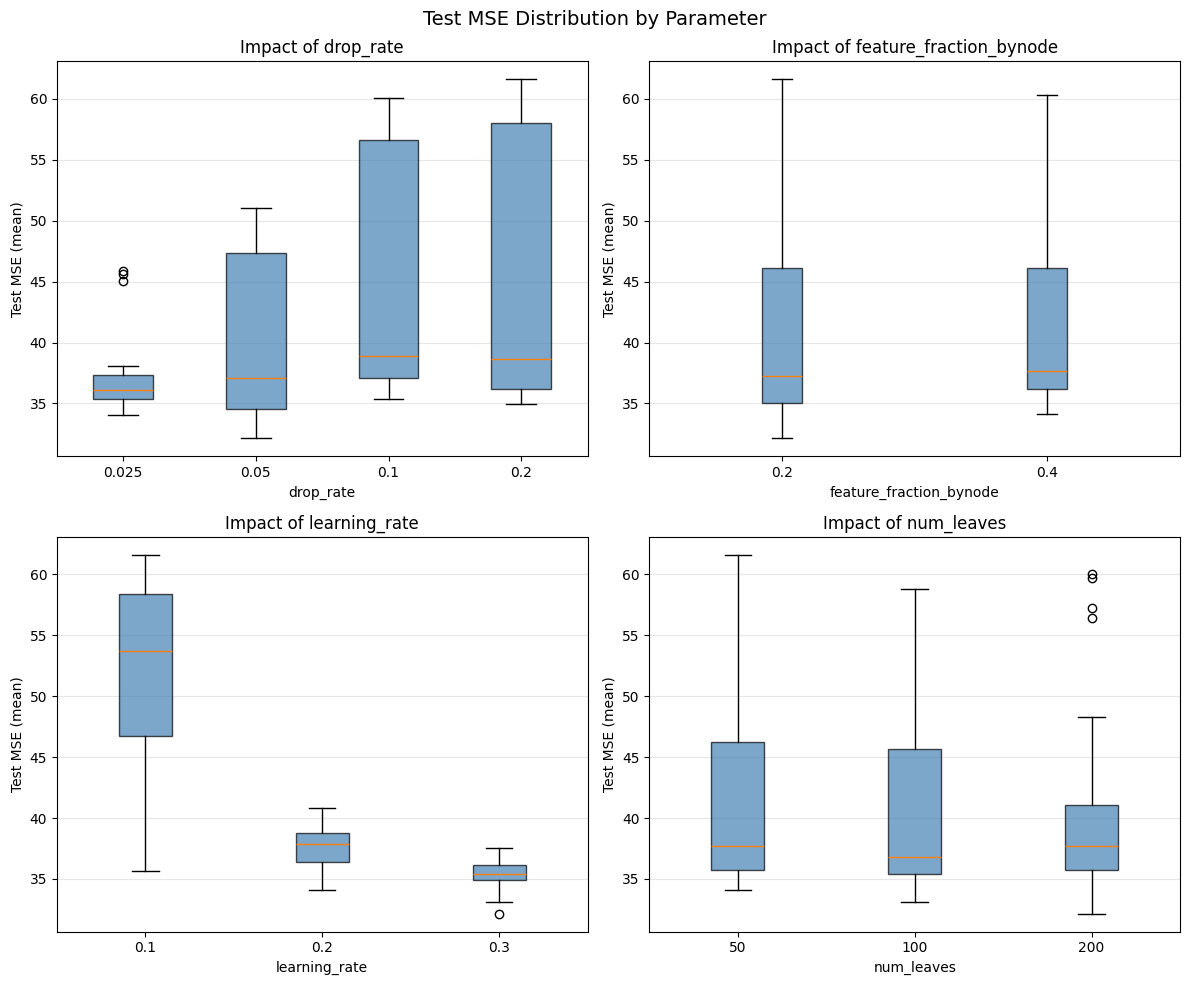

In [91]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Test MSE Distribution by Parameter', fontsize=14)

for ax, param in zip(axes.flat, param_cols):
    grouped = df.groupby(param)['test_mse_mean'].apply(list)
    box_data = [grouped[k] for k in sorted(grouped.index)]
    labels = [str(k) for k in sorted(grouped.index)]
    
    bp = ax.boxplot(box_data, tick_labels=labels, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.7)
    
    ax.set_xlabel(param)
    ax.set_ylabel('Test MSE (mean)')
    ax.set_title(f'Impact of {param}')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


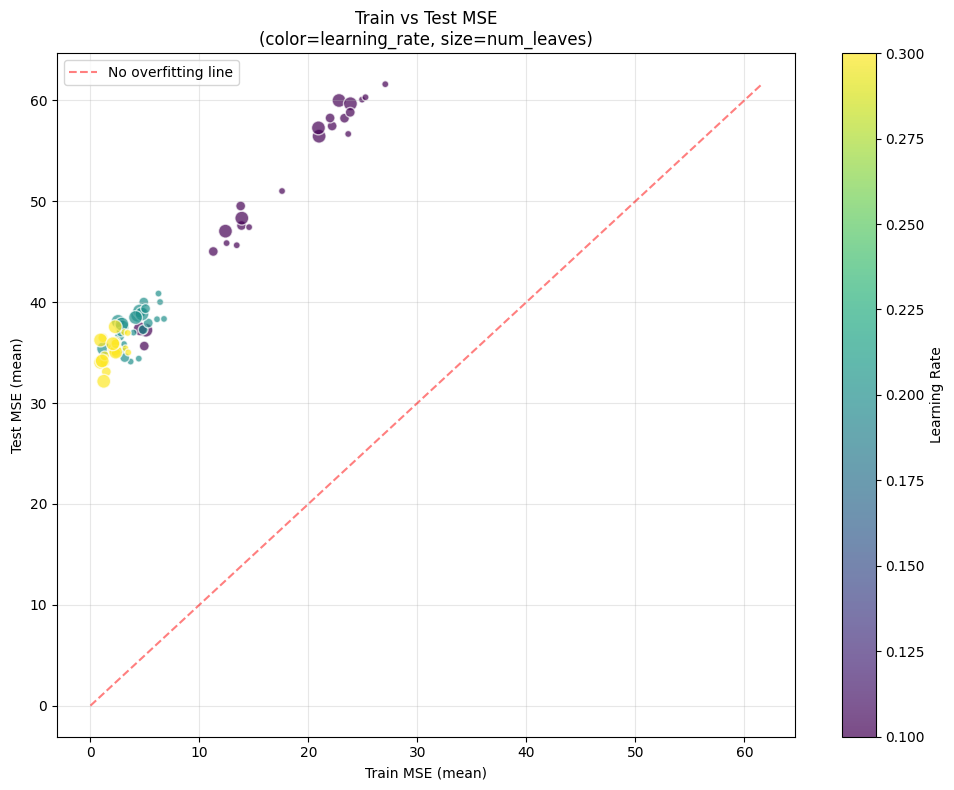

In [92]:
# Train vs Test MSE scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(df['train_mse_mean'], df['test_mse_mean'], 
                     c=df['learning_rate'], cmap='viridis', 
                     s=df['num_leaves']/2, alpha=0.7, edgecolors='white')

# Add diagonal line (perfect fit = no overfitting)
lims = [0, max(df['test_mse_mean'].max(), df['train_mse_mean'].max())]
ax.plot(lims, lims, 'r--', alpha=0.5, label='No overfitting line')

ax.set_xlabel('Train MSE (mean)')
ax.set_ylabel('Test MSE (mean)')
ax.set_title('Train vs Test MSE\n(color=learning_rate, size=num_leaves)')
ax.legend()
ax.grid(alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('Learning Rate')

plt.tight_layout()
plt.show()


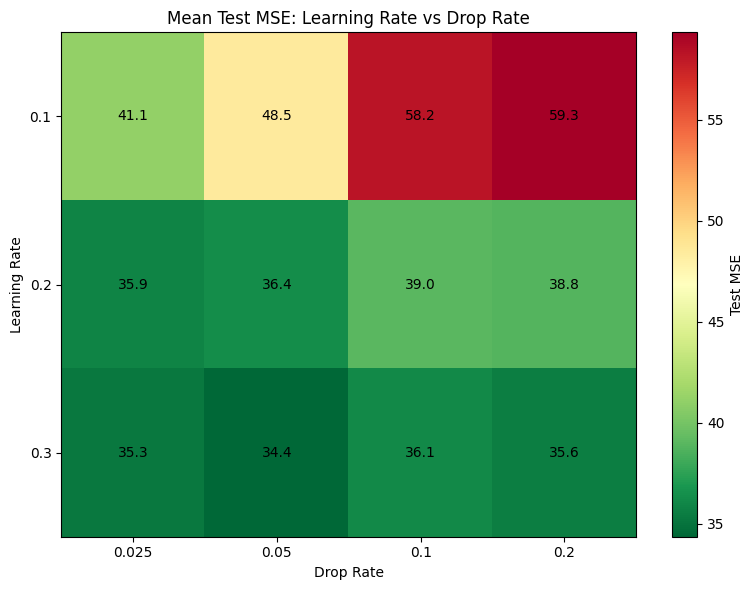

In [93]:
# Heatmap of learning_rate vs drop_rate
pivot = df.pivot_table(values='test_mse_mean', 
                       index='learning_rate', 
                       columns='drop_rate', 
                       aggfunc='mean')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Drop Rate')
ax.set_ylabel('Learning Rate')
ax.set_title('Mean Test MSE: Learning Rate vs Drop Rate')

# Add values to cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        text = ax.text(j, i, f'{pivot.values[i, j]:.1f}',
                       ha='center', va='center', color='black', fontsize=10)

plt.colorbar(im, label='Test MSE')
plt.tight_layout()
plt.show()


## Best Model Detailed Analysis

Detailed fold-by-fold results for the best configuration.


In [94]:
# Find the best model based on test_mse_mean
best_idx = df['test_mse_mean'].idxmin()
best_row = df.loc[best_idx]

# Find the corresponding raw data
best_params = {
    'drop_rate': best_row['drop_rate'],
    'feature_fraction_bynode': best_row['feature_fraction_bynode'],
    'learning_rate': best_row['learning_rate'],
    'num_leaves': best_row['num_leaves'],
}

# Find matching experiment in raw data
best_experiment = None
for exp in data['results']:
    params = exp['full_params']
    if (params.get('drop_rate') == best_params['drop_rate'] and
        params.get('feature_fraction_bynode') == best_params['feature_fraction_bynode'] and
        params.get('learning_rate') == best_params['learning_rate'] and
        params.get('num_leaves') == best_params['num_leaves']):
        best_experiment = exp
        break

print("Best Configuration Parameters:")
print("-" * 40)
for k, v in best_experiment['full_params'].items():
    print(f"  {k}: {v}")

print(f"\nOverall Performance:")
print("-" * 40)
print(f"  Mean Test MSE:  {best_row['test_mse_mean']:.4f}")
print(f"  Std Test MSE:   {best_row['test_mse_std']:.4f}")
print(f"  Mean Train MSE: {best_row['train_mse_mean']:.4f}")
print(f"  Overfit Ratio:  {best_row['overfit_ratio']:.4f}")


Best Configuration Parameters:
----------------------------------------
  objective: regression
  boosting_type: dart
  metric: mse
  verbose: -1
  max_depth: 10
  drop_rate: 0.05
  feature_fraction_bynode: 0.2
  learning_rate: 0.3
  num_leaves: 200

Overall Performance:
----------------------------------------
  Mean Test MSE:  32.1532
  Std Test MSE:   17.7412
  Mean Train MSE: 1.2167
  Overfit Ratio:  26.4261


Fold-by-Fold Results for Best Configuration:


,fold_idx,train_mse,test_mse,train_samples,test_samples,overfit_ratio
0,0,1.816704,18.824624,49402,4098,10.361966
1,1,0.603382,23.181290,47825,5675,38.418953
2,2,1.599256,29.171403,45991,7509,18.240607
3,3,1.153607,43.302119,46702,6798,37.536268
4,4,2.239332,24.671569,48891,4609,11.017379
5,5,0.658694,59.416631,48746,4754,90.203671
6,6,1.159696,68.717559,48469,5031,59.254805
7,7,0.748964,16.950304,48768,4732,22.631655
8,8,0.826146,22.115366,48072,5428,26.769314
9,9,1.361396,15.180734,48634,4866,11.150861


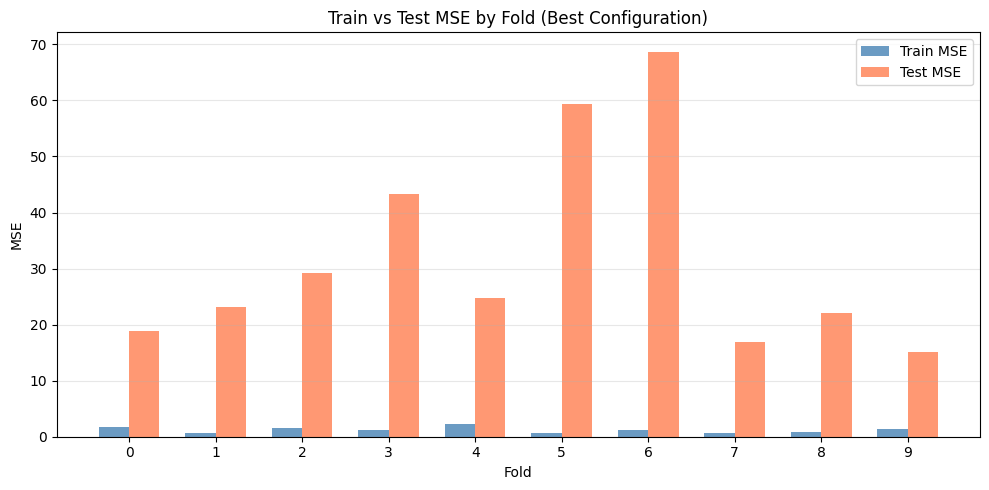

In [95]:
# Fold-level results for best model
fold_df = pd.DataFrame(best_experiment['fold_results'])
fold_df['overfit_ratio'] = fold_df['test_mse'] / fold_df['train_mse']

print("Fold-by-Fold Results for Best Configuration:")
print("=" * 60)
display(fold_df)

# Visualize fold results
fig, ax = plt.subplots(figsize=(10, 5))
x = fold_df['fold_idx']
width = 0.35

bars1 = ax.bar(x - width/2, fold_df['train_mse'], width, label='Train MSE', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, fold_df['test_mse'], width, label='Test MSE', color='coral', alpha=0.8)

ax.set_xlabel('Fold')
ax.set_ylabel('MSE')
ax.set_title('Train vs Test MSE by Fold (Best Configuration)')
ax.set_xticks(x)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Summary Statistics


In [96]:
print("=" * 60)
print("GRID SEARCH SUMMARY")
print("=" * 60)
print(f"\nTotal configurations tested: {len(df)}")
print(f"Cross-validation folds: {data['n_folds']}")
print(f"\nTest MSE Statistics:")
print(f"  Best:  {df['test_mse_mean'].min():.4f}")
print(f"  Worst: {df['test_mse_mean'].max():.4f}")
print(f"  Mean:  {df['test_mse_mean'].mean():.4f}")
print(f"  Std:   {df['test_mse_mean'].std():.4f}")

print(f"\nBest parameters:")
for k in ['drop_rate', 'feature_fraction_bynode', 'learning_rate', 'num_leaves']:
    print(f"  {k}: {best_row[k]}")
print("=" * 60)


GRID SEARCH SUMMARY

Total configurations tested: 72
Cross-validation folds: 10

Test MSE Statistics:
  Best:  32.1532
  Worst: 61.6045
  Mean:  41.5570
  Std:   8.7325

Best parameters:
  drop_rate: 0.05
  feature_fraction_bynode: 0.2
  learning_rate: 0.3
  num_leaves: 200.0
